In [1]:
import re
import pandas as pd
from pathlib import Path

# graph
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from pathlib import Path
import re
import pandas as pd

def get_metrics_from_log(log_path):
    log_path = Path(f"./logs/{log_path}_train.log")
    text = log_path.read_text(encoding="utf-8")

    # 마지막 Evaluation Metrics 블록 파싱
    m = re.search(
        r"=== Evaluation Metrics ===\s*"
        r"Recall @3 @5 @10 @20:\s*([\d.]+)\s*([\d.]+)\s*([\d.]+)\s*([\d.]+)\s*"
        r"NDCG @3 @5 @10 @20:\s*([\d.]+)\s*([\d.]+)\s*([\d.]+)\s*([\d.]+)\s*"
        r"MRR @3 @5 @10 @20:\s*([\d.]+)\s*([\d.]+)\s*([\d.]+)\s*([\d.]+)",
        text,
        flags=re.S,
    )

    if m:
        ks = [3, 5, 10, 20]
        rec = list(map(float, m.group(1, 2, 3, 4)))
        ndcg = list(map(float, m.group(5, 6, 7, 8)))
        mrr = list(map(float, m.group(9, 10, 11, 12)))
        final_df = pd.DataFrame({"K": ks, "Recall": rec, "NDCG": ndcg, "MRR": mrr})
        return final_df
    else:
        print("Evaluation Metrics 블록을 못 찾음")
        return None

In [7]:
# before dbo
#ls_logs = [("100", '20260406_121339'), ("100_10", '20260406_084634')
#        , ("100_50", '20260406_101913'), ("100_90", '20260406_014743')]

ls_logs = [("100", '20260413_085202'), ("100_10", '20260412_211833')
        , ("100_50", '20260412_233429'), ("100_90", '20260412_222359'), ("100_100", '20260413_100224')]

all_df = []

for test_type, log in ls_logs:
    df_m = get_metrics_from_log(log)
    df_m['test_type'] = test_type
    
    all_df.append(df_m)

result_df = pd.concat(all_df, ignore_index=True)


In [3]:
# before_dbo
#ls_logs = [("half", '20260408_015455'), ("half_10", '20260407_222013')
#        , ("half_50", '20260408_000556'), ("half_90", '20260407_200742')]

# dbo
#ls_logs = [("half", '20260413_184439'), ("half_10", '20260413_114012')
#        , ("half_50", '20260413_131720'), ("half_90", '20260413_150114'), ("half_100", '20260413_203056')]

# cano
ls_logs = [("case_0", '20260413_184439'), ("case_10", '20260416_051745'), ("case_30", '20260416_224443')
        , ("case_50", '20260416_063855'), ("case_70", '20260417_005030'), ("case_90", '20260416_002243'), ("case_100", '20260416_205636')]

all_df = []

for test_type, log in ls_logs:
    df_m = get_metrics_from_log(log)
    df_m['test_type'] = test_type
    
    all_df.append(df_m)

result_df = pd.concat(all_df, ignore_index=True)


In [8]:
result_df.to_csv("test_result_itemCNT_100_dbo.csv", sep=',')

In [35]:
result_df.to_csv("test_result_itemCNT_half_cano.csv", sep=',')

In [ ]:
movies_half_filtered_kg_random_100.tail(5)

,head_id:token,relation_id:token,tail_id:token,title
1980,res:Fargo_(season_2),dct:subject,cat:Cultural_depictions_of_Ronald_Reagan,res:Fargo_(season_2)
1981,res:Fargo_(season_2),dct:subject,cat:Television_series_set_in_1979,res:Fargo_(season_2)
1982,res:Fargo_(season_2),dct:subject,cat:Alien_visitations_in_fiction,res:Fargo_(season_2)
1983,res:Fargo_(season_2),dct:subject,cat:Fargo_(TV_series)_episodes,res:Fargo_(season_2)
1984,res:Fargo_(season_2),dct:subject,cat:2015_American_television_seasons,res:Fargo_(season_2)


In [22]:
result_df['p_temp'] = result_df['test_type'].apply(lambda x: x.split('_')[1]).astype('float')
result_df.tail(100)

,K,Recall,NDCG,MRR,test_type,p,p_temp
0,3,0.0415,0.0308,0.0271,case_0,0.0,0.0
1,5,0.0618,0.0391,0.0317,case_0,0.0,0.0
2,10,0.0945,0.0496,0.0360,case_0,0.0,0.0
3,20,0.1412,0.0613,0.0391,case_0,0.0,0.0
4,3,0.0411,0.0307,0.0271,case_10,0.1,10.0
5,5,0.0599,0.0384,0.0314,case_10,0.1,10.0
6,10,0.0920,0.0488,0.0356,case_10,0.1,10.0
7,20,0.1372,0.0601,0.0387,case_10,0.1,10.0
8,3,0.0423,0.0309,0.0270,case_30,0.3,30.0
9,5,0.0604,0.0383,0.0311,case_30,0.3,30.0


In [16]:
result_df['p'] = result_df['p_temp']/100
result_df.tail(5)

,K,Recall,NDCG,MRR,test_type,p,p_temp
23,20,0.1376,0.0597,0.0382,case_90,0.9,90.0
24,3,0.0414,0.0307,0.0271,case_100,1.0,100.0
25,5,0.0599,0.0384,0.0313,case_100,1.0,100.0
26,10,0.0931,0.0490,0.0357,case_100,1.0,100.0
27,20,0.1367,0.0600,0.0387,case_100,1.0,100.0


In [49]:
df = result_df
pair_rows = []
for k in [3, 5, 10, 20]:
    dk = df[df["K"] == k][["test_type", "p", "NDCG"]].copy()
    dk["p_partner"] = 1.0 - dk["p"]
    right = dk.rename(columns={
        "test_type": "test_type_partner",
        "NDCG": "NDCG_partner",
    })[["p_partner", "test_type_partner", "NDCG_partner"]]
    merged = dk.merge(right, left_on = 'p', right_on='p_partner', how="inner")
    merged = merged[merged["p"] >= merged["p_partner_x"]]  # 0.3–0.7 한 번만
    merged["K"] = k
    merged["homogeneity"] = (merged["NDCG"] + merged["NDCG_partner"]) / 2
    pair_rows.append(merged)
homogeneity_df = pd.concat(pair_rows, ignore_index=True)
#homogeneity_df[["K", "test_type", "p", "test_type_partner", "NDCG", "NDCG_partner", "homogeneity"]]


In [52]:
homogeneity_df

,test_type,p,NDCG,p_partner_x,p_partner_y,test_type_partner,NDCG_partner,K,homogeneity
0,case_50,0.5,0.0303,0.5,0.5,case_50,0.0303,3,0.03030
1,case_70,0.7,0.0302,0.3,0.7,case_30,0.0309,3,0.03055
2,case_90,0.9,0.0307,0.1,0.9,case_10,0.0307,3,0.03070
3,case_100,1.0,0.0307,0.0,1.0,case_0,0.0308,3,0.03075
4,case_50,0.5,0.0371,0.5,0.5,case_50,0.0371,5,0.03710
5,case_70,0.7,0.0380,0.3,0.7,case_30,0.0383,5,0.03815
6,case_90,0.9,0.0378,0.1,0.9,case_10,0.0384,5,0.03810
7,case_100,1.0,0.0384,0.0,1.0,case_0,0.0391,5,0.03875
8,case_50,0.5,0.0474,0.5,0.5,case_50,0.0474,10,0.04740
9,case_70,0.7,0.0482,0.3,0.7,case_30,0.0478,10,0.04800


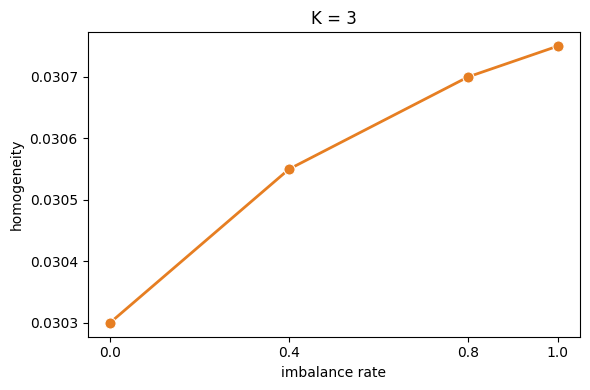

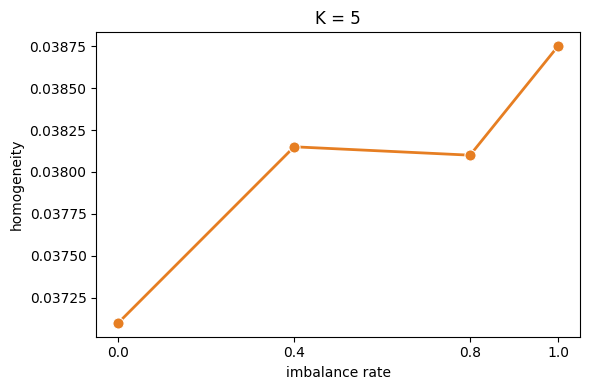

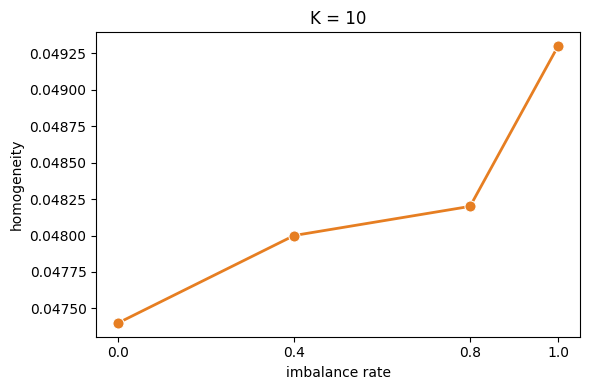

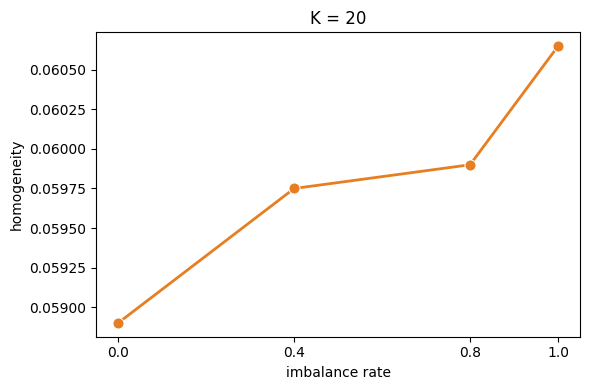

In [55]:
homogeneity_df["imbalance_rate"] = 2 * (homogeneity_df["p"] - 0.5).abs()
ORANGE = "#E67E22"  # 주황 (원하면 "#F39C12", "#FF7F0E" 등)
for k in [3, 5, 10, 20]:
    sub = homogeneity_df[homogeneity_df["K"] == k].sort_values("imbalance_rate")
    plt.figure(figsize=(6, 4))
    sns.lineplot(
        data=sub,
        x="imbalance_rate",
        y="homogeneity",
        marker="o",
        color=ORANGE,
        linewidth=2,
        markersize=8,
    )
    plt.xlim(-0.05, 1.05)
    plt.xticks([0, 0.4, 0.8, 1.0])
    plt.xlabel("imbalance rate")
    plt.ylabel("homogeneity")
    plt.title(f"K = {k}")
    plt.tight_layout()
    plt.show()

In [57]:
df = result_df
pair_rows = []
for k in [3, 5, 10, 20]:
    dk = df[df["K"] == k][["test_type", "p", "MRR"]].copy()
    dk["p_partner"] = 1.0 - dk["p"]
    right = dk.rename(columns={
        "test_type": "test_type_partner",
        "MRR": "MRR_partner",
    })[["p_partner", "test_type_partner", "MRR_partner"]]
    merged = dk.merge(right, left_on = 'p', right_on='p_partner', how="inner")
    merged = merged[merged["p"] >= merged["p_partner_x"]]  # 0.3–0.7 한 번만
    merged["K"] = k
    merged["homogeneity"] = (merged["MRR"] + merged["MRR_partner"]) / 2
    pair_rows.append(merged)
homogeneity_df2 = pd.concat(pair_rows, ignore_index=True)
#homogeneity_df[["K", "test_type", "p", "test_type_partner", "NDCG", "NDCG_partner", "homogeneity"]]


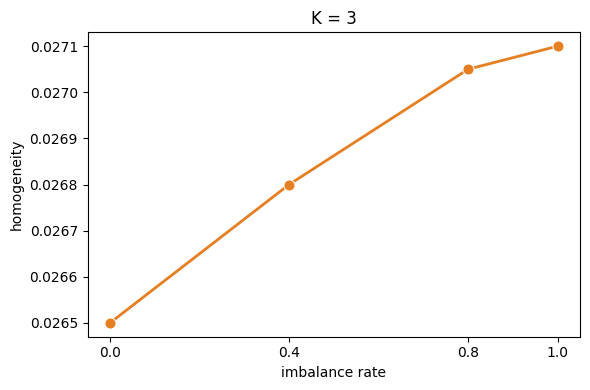

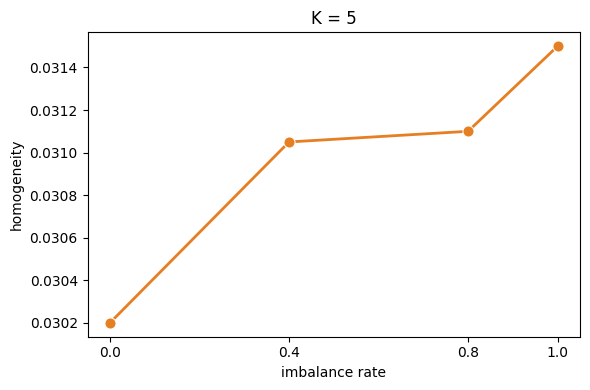

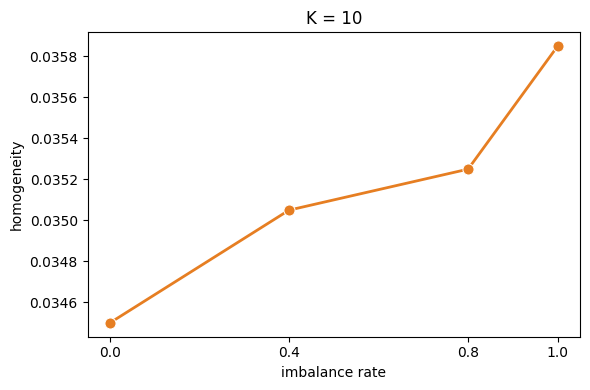

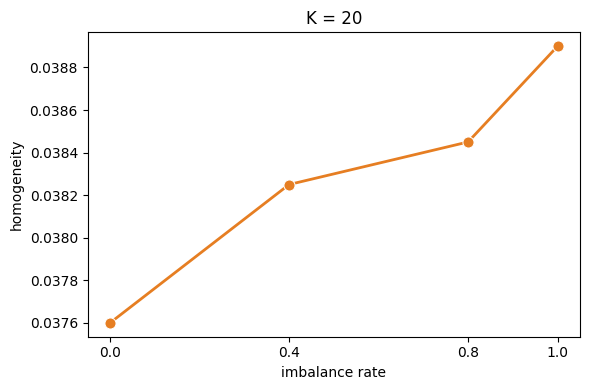

In [58]:
homogeneity_df2["imbalance_rate"] = 2 * (homogeneity_df2["p"] - 0.5).abs()
ORANGE = "#E67E22"  # 주황 (원하면 "#F39C12", "#FF7F0E" 등)
for k in [3, 5, 10, 20]:
    sub2 = homogeneity_df2[homogeneity_df2["K"] == k].sort_values("imbalance_rate")
    plt.figure(figsize=(6, 4))
    sns.lineplot(
        data=sub2,
        x="imbalance_rate",
        y="homogeneity",
        marker="o",
        color=ORANGE,
        linewidth=2,
        markersize=8,
    )
    plt.xlim(-0.05, 1.05)
    plt.xticks([0, 0.4, 0.8, 1.0])
    plt.xlabel("imbalance rate")
    plt.ylabel("homogeneity")
    plt.title(f"K = {k}")
    plt.tight_layout()
    plt.show()

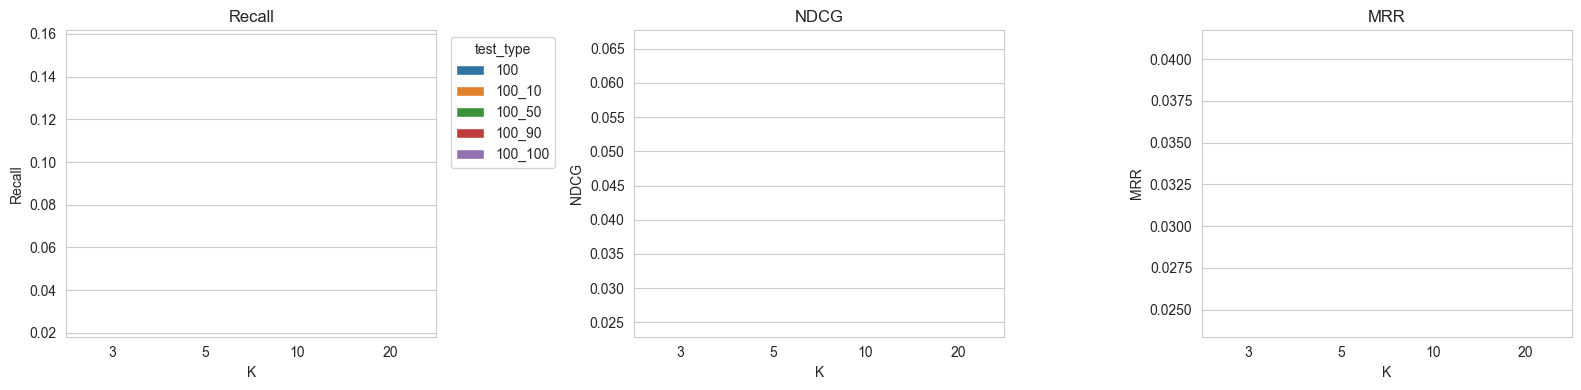

In [11]:
plot_df = result_df.copy()  # 네 df 이름으로 바꿔도 됨
plot_df["K"] = plot_df["K"].astype(int)
plot_df["test_type"] = plot_df["test_type"].astype(str)
# 범례 순서 원하는대로
hue_order = ["100", "100_10", "100_50", "100_90", "100_100"]
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
sns.barplot(
  data=plot_df, x="K", y="Recall", hue="test_type",
  order=[3, 5, 10, 20], hue_order=hue_order, ax=axes[0]
)
axes[0].set_title("Recall")
axes[0].set_xlabel("K")
sns.barplot(
  data=plot_df, x="K", y="NDCG", hue="test_type",
  order=[3, 5, 10, 20], hue_order=hue_order, ax=axes[1]
)
axes[1].set_title("NDCG")
axes[1].set_xlabel("K")
sns.barplot(
  data=plot_df, x="K", y="MRR", hue="test_type",
  order=[3, 5, 10, 20], hue_order=hue_order, ax=axes[2]
)
axes[2].set_title("MRR")
axes[2].set_xlabel("K")
# 범례는 하나만
axes[1].legend_.remove()
axes[2].legend_.remove()
axes[0].legend(title="test_type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

for ax, col in zip(axes, ["Recall", "NDCG", "MRR"]):
  ymin = plot_df[col].min()
  ymax = plot_df[col].max()
  pad = (ymax - ymin) * 0.2 if ymax > ymin else 0.001
  ax.set_ylim(ymin - pad, ymax + pad)
  
plt.show()


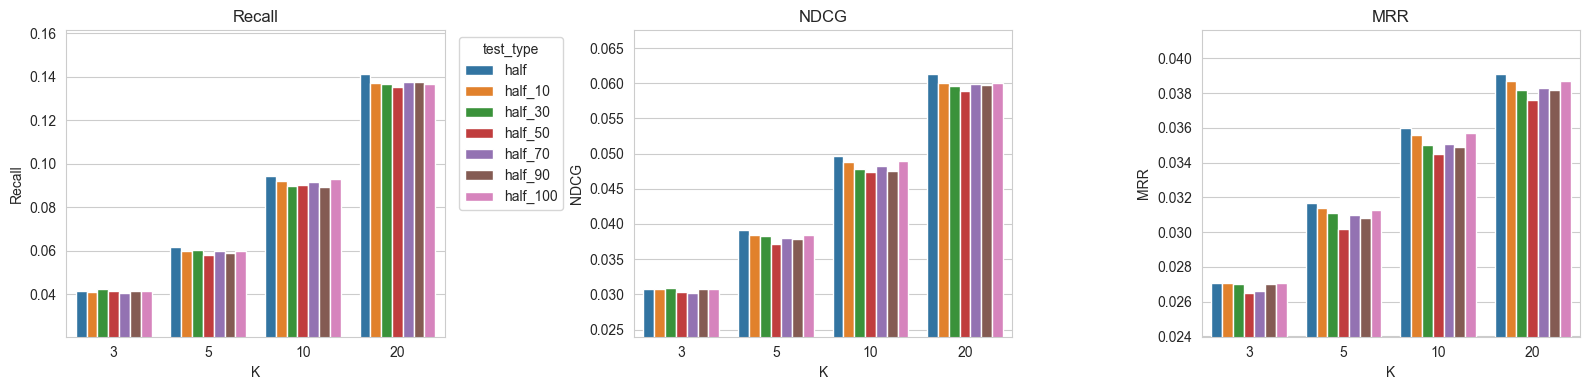

In [38]:
plot_df = result_df.copy()  # 네 df 이름으로 바꿔도 됨
plot_df["K"] = plot_df["K"].astype(int)
plot_df["test_type"] = plot_df["test_type"].astype(str)
# 범례 순서 원하는대로
hue_order = ["half", "half_10","half_30", "half_50", "half_70", "half_90", "half_100"]
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
sns.barplot(
  data=plot_df, x="K", y="Recall", hue="test_type",
  order=[3, 5, 10, 20], hue_order=hue_order, ax=axes[0]
)
axes[0].set_title("Recall")
axes[0].set_xlabel("K")
sns.barplot(
  data=plot_df, x="K", y="NDCG", hue="test_type",
  order=[3, 5, 10, 20], hue_order=hue_order, ax=axes[1]
)
axes[1].set_title("NDCG")
axes[1].set_xlabel("K")
sns.barplot(
  data=plot_df, x="K", y="MRR", hue="test_type",
  order=[3, 5, 10, 20], hue_order=hue_order, ax=axes[2]
)
axes[2].set_title("MRR")
axes[2].set_xlabel("K")
# 범례는 하나만
axes[1].legend_.remove()
axes[2].legend_.remove()
axes[0].legend(title="test_type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

for ax, col in zip(axes, ["Recall", "NDCG", "MRR"]):
  ymin = plot_df[col].min()
  ymax = plot_df[col].max()
  pad = (ymax - ymin) * 0.2 if ymax > ymin else 0.001
  ax.set_ylim(ymin - pad, ymax + pad)
  
plt.show()


In [12]:
base = "half"
tmp = result_df.copy()
base_df = tmp[tmp["test_type"] == base][["K", "Recall", "NDCG", "MRR"]].set_index("K")
for m in ["Recall", "NDCG", "MRR"]:
  tmp[f"{m}_delta_pct"] = tmp.apply(
      lambda r: (r[m] - base_df.loc[r["K"], m]) / base_df.loc[r["K"], m] * 100,
      axis=1
  )


In [14]:
base = "half"
tmp = result_df.copy()
base_df = tmp[tmp["test_type"] == base][["K", "Recall", "NDCG", "MRR"]].set_index("K")
for m in ["Recall", "NDCG", "MRR"]:
  tmp[f"{m}_delta_pct"] = tmp.apply(
      lambda r: (r[m] - base_df.loc[r["K"], m]) / base_df.loc[r["K"], m] * 100,
      axis=1
  )


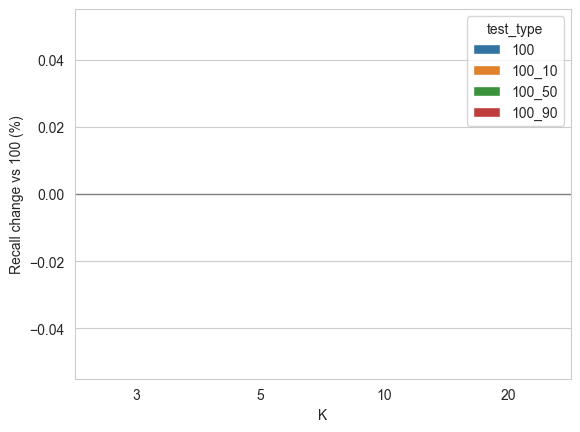

In [79]:
# 예: Recall 변화율만
sns.barplot(data=tmp, x="K", y="Recall_delta_pct", hue="test_type",
          order=[3,5,10,20], hue_order=["100","100_10","100_50","100_90"])
plt.axhline(0, color="gray", lw=1)
plt.ylabel("Recall change vs 100 (%)")
plt.show()

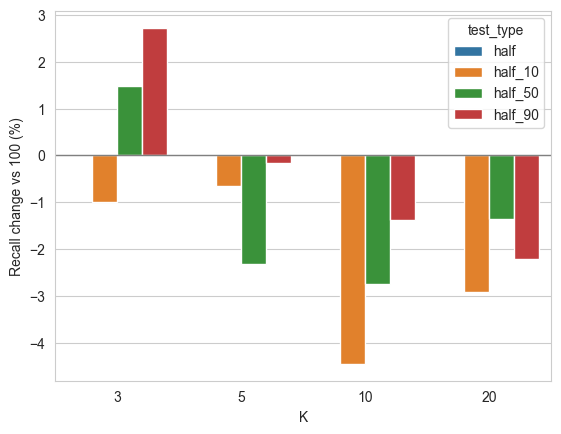

In [60]:
# 예: Recall 변화율만
sns.barplot(data=tmp, x="K", y="Recall_delta_pct", hue="test_type",
          order=[3,5,10,20], hue_order=["half","half_10","half_50","half_90"])
plt.axhline(0, color="gray", lw=1)
plt.ylabel("Recall change vs 100 (%)")
plt.show()

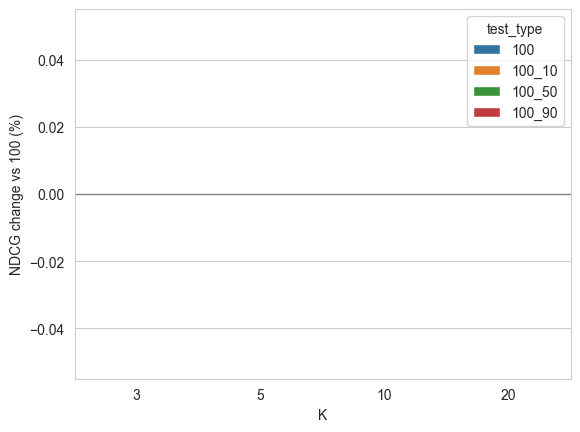

In [15]:
# 예: Recall 변화율만
sns.barplot(data=tmp, x="K", y="NDCG_delta_pct", hue="test_type",
          order=[3,5,10,20], hue_order=["100","100_10","100_50","100_90"])
plt.axhline(0, color="gray", lw=1)
plt.ylabel("NDCG change vs 100 (%)")
plt.show()

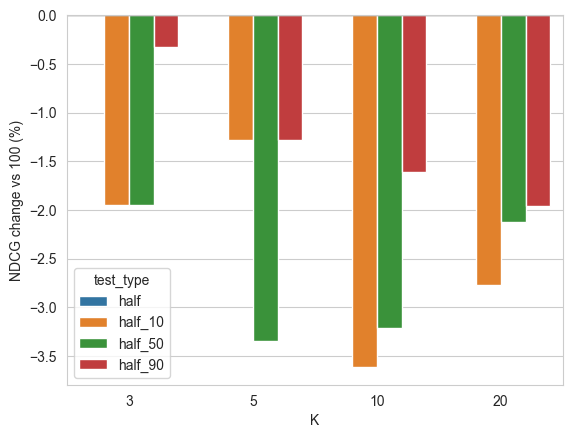

In [61]:
# 예: Recall 변화율만
sns.barplot(data=tmp, x="K", y="NDCG_delta_pct", hue="test_type",
          order=[3,5,10,20], hue_order=["half","half_10","half_50","half_90"])
plt.axhline(0, color="gray", lw=1)
plt.ylabel("NDCG change vs 100 (%)")
plt.show()

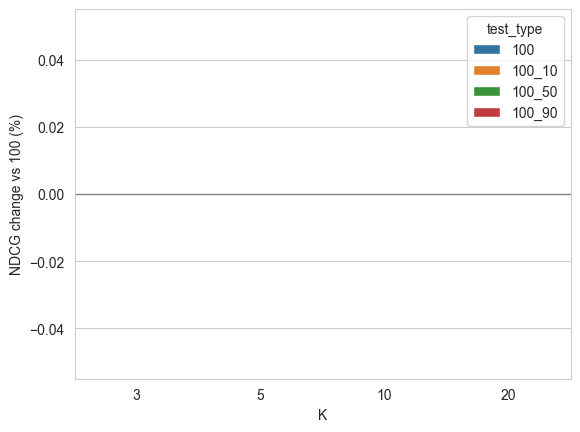

In [16]:
# 예: Recall 변화율만
sns.barplot(data=tmp, x="K", y="MRR_delta_pct", hue="test_type",
          order=[3,5,10,20], hue_order=["100","100_10","100_50","100_90"])
plt.axhline(0, color="gray", lw=1)
plt.ylabel("NDCG change vs 100 (%)")
plt.show()

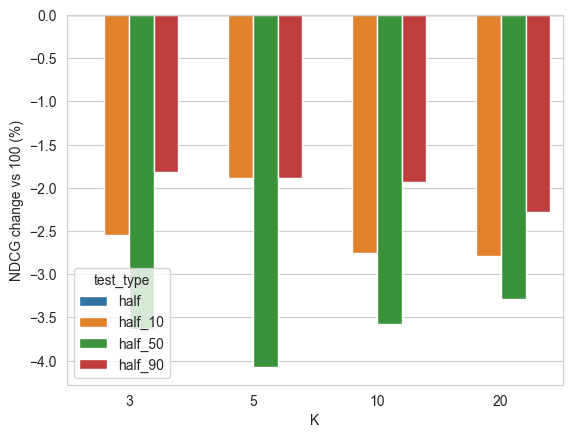

In [62]:
# 예: Recall 변화율만
sns.barplot(data=tmp, x="K", y="MRR_delta_pct", hue="test_type",
          order=[3,5,10,20], hue_order=["half","half_10","half_50","half_90"])
plt.axhline(0, color="gray", lw=1)
plt.ylabel("NDCG change vs 100 (%)")
plt.show()

In [ ]:
import pandas as pd

def compare_k10_table(df, baseline="100"):
    # 타입 정리
    t = df.copy()
    t["K"] = t["K"].astype(int)
    t["test_type"] = t["test_type"].astype(str)

    # K=10만
    k10 = t[t["K"] == 10][["test_type", "Recall", "NDCG", "MRR"]].copy()
    k10 = k10.drop_duplicates(subset=["test_type"]).set_index("test_type")

    if baseline not in k10.index:
        raise ValueError(f"baseline '{baseline}' not found in test_type")

    # baseline 대비 변화율(%)
    base = k10.loc[baseline]
    for m in ["Recall", "NDCG", "MRR"]:
        k10[f"{m}_chg_vs_{baseline}(%)"] = (k10[m] - base[m]) / base[m] * 100

    # 보기 좋게
    out = k10.reset_index()
    preferred_order = ["100", "100_10", "100_50", "100_90"]
    out["order"] = out["test_type"].apply(lambda x: preferred_order.index(x) if x in preferred_order else 999)
    out = out.sort_values("order").drop(columns="order")

    # 소수점 정리
    metric_cols = ["Recall", "NDCG", "MRR"]
    chg_cols = [c for c in out.columns if "chg_vs_" in c]
    out[metric_cols] = out[metric_cols].round(4)
    out[chg_cols] = out[chg_cols].round(2)

    return out

k10_table = compare_k10_table(result_df, baseline="100")
display(k10_table)

,test_type,Recall,NDCG,MRR,Recall_chg_vs_100(%),NDCG_chg_vs_100(%),MRR_chg_vs_100(%)
0,100,0.0917,0.0488,0.0359,0.00,0.00,0.00
1,100_10,0.0919,0.0490,0.0360,0.22,0.41,0.28
2,100_50,0.0926,0.0485,0.0351,0.98,-0.61,-2.23
3,100_90,0.0935,0.0486,0.0351,1.96,-0.41,-2.23


In [63]:
import pandas as pd

def compare_k10_table(df, baseline="half"):
    # 타입 정리
    t = df.copy()
    t["K"] = t["K"].astype(int)
    t["test_type"] = t["test_type"].astype(str)

    # K=10만
    k10 = t[t["K"] == 10][["test_type", "Recall", "NDCG", "MRR"]].copy()
    k10 = k10.drop_duplicates(subset=["test_type"]).set_index("test_type")

    if baseline not in k10.index:
        raise ValueError(f"baseline '{baseline}' not found in test_type")

    # baseline 대비 변화율(%)
    base = k10.loc[baseline]
    for m in ["Recall", "NDCG", "MRR"]:
        k10[f"{m}_chg_vs_{baseline}(%)"] = (k10[m] - base[m]) / base[m] * 100

    # 보기 좋게
    out = k10.reset_index()
    preferred_order = ["half", "half_10", "half_50", "half_90"]
    out["order"] = out["test_type"].apply(lambda x: preferred_order.index(x) if x in preferred_order else 999)
    out = out.sort_values("order").drop(columns="order")

    # 소수점 정리
    metric_cols = ["Recall", "NDCG", "MRR"]
    chg_cols = [c for c in out.columns if "chg_vs_" in c]
    out[metric_cols] = out[metric_cols].round(4)
    out[chg_cols] = out[chg_cols].round(2)

    return out

k10_table = compare_k10_table(result_df, baseline="half")
display(k10_table)

,test_type,Recall,NDCG,MRR,Recall_chg_vs_half(%),NDCG_chg_vs_half(%),MRR_chg_vs_half(%)
0,half,0.0943,0.0498,0.0363,0.00,0.00,0.00
1,half_10,0.0901,0.0480,0.0353,-4.45,-3.61,-2.75
2,half_50,0.0917,0.0482,0.0350,-2.76,-3.21,-3.58
3,half_90,0.0930,0.0490,0.0356,-1.38,-1.61,-1.93


In [ ]:
test_result_itemCNT_100

In [ ]:
k10_table.to_csv("./test_result_itemCNT_100_k10_metrics_comparison.csv", index=False)

In [64]:
k10_table.to_csv("./test_result_itemCNT_half_k10_metrics_comparison.csv", index=False)